In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, make_scorer
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
df = pd.read_csv('C:/Users/User/Desktop/cardiovascular_risk_dataset.csv')


D:\Aninst\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


In [3]:
df.describe()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

In [5]:
list_columns = ['smoking_status', 'family_history_heart_disease', 'risk_category']
for i in list_columns:
    print(df[i].unique())

['Never' 'Current' 'Former']
['No' 'Yes']
['Medium' 'High' 'Low']


In [2]:
df['smoking_status'] = df['smoking_status'].map({'Never': 1, 'Current': 2, 'Former': 0}).astype(float)
df['family_history_heart_disease'] = df['family_history_heart_disease'].map({'No': 0, 'Yes': 1}).astype(float)
df['risk_category'] = df['risk_category'].map({'Medium': 1, 'High': 2, 'Low': 0}).astype(float)

In [3]:
df1 = df.drop(columns=['Patient_ID'])

In [8]:
df1

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,62,25.0,142,93,247,72,1.0,11565,3,5.6,8.2,0.0,7,0.7,28.1,1.0
1,54,29.7,158,101,254,74,2.0,4036,8,0.5,6.7,0.0,5,4.5,63.0,2.0
2,46,36.2,170,113,276,80,2.0,3043,9,0.4,4.0,0.0,1,20.8,73.1,2.0
3,48,30.4,153,98,230,73,0.0,5604,5,0.6,8.0,0.0,4,8.5,39.5,1.0
4,46,25.3,139,87,206,69,2.0,7464,1,2.0,6.1,0.0,5,3.6,29.3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,19,26.0,121,75,185,84,1.0,6724,3,2.9,7.2,0.0,7,0.0,0.0,0.0
5496,18,30.9,128,82,235,75,1.0,3661,4,0.0,5.5,0.0,1,9.6,16.8,0.0
5497,63,29.5,142,92,239,69,1.0,6643,5,4.1,6.9,0.0,6,2.4,31.8,1.0
5498,46,27.5,138,91,237,65,1.0,3279,3,2.4,5.8,1.0,5,2.3,29.4,1.0


In [9]:
df1.isna().sum()

age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

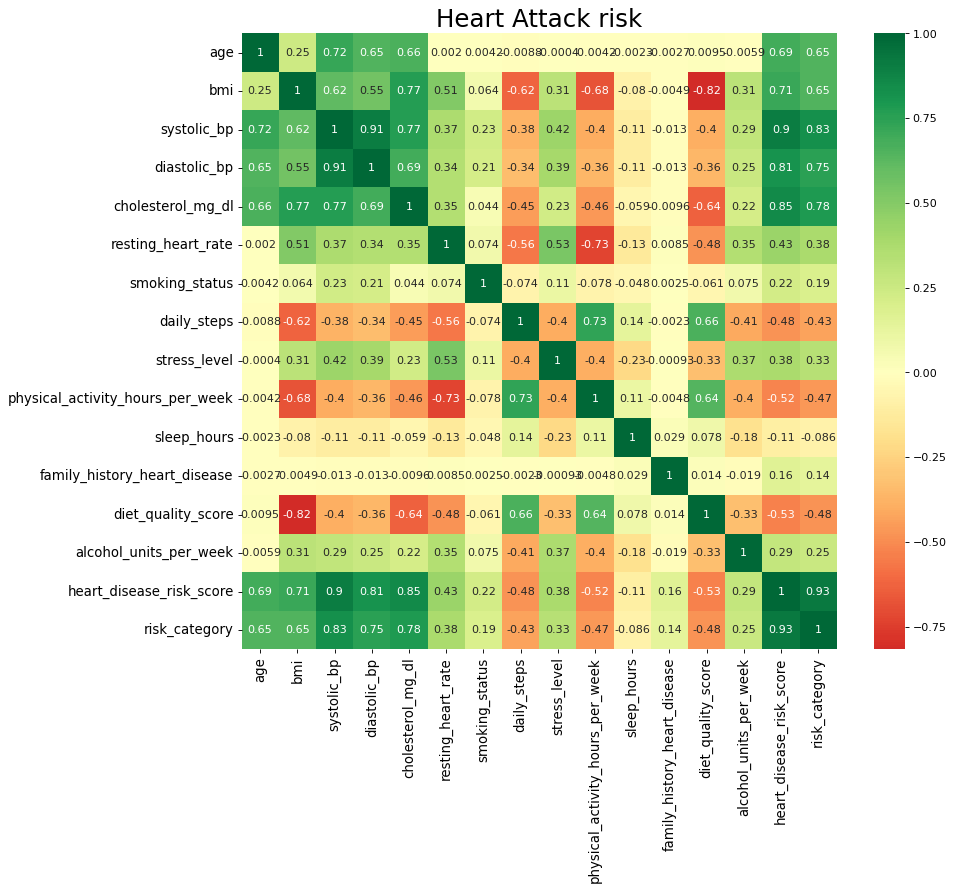

In [10]:
heatdf = df1
plt.figure(figsize = (12,10), dpi = 80)
sns.heatmap(heatdf.corr(), xticklabels = heatdf.corr().columns, yticklabels = heatdf.corr().columns, cmap = 'RdYlGn', center = 0, annot = True)
plt.title('Heart Attack risk', fontsize = 22)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

x = df.drop(['risk_category'], axis = 1).to_numpy()
y = df['risk_category'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
def create_pairs(x_train_scaled, x_test_scaled, y_train, y_test):
    tensor_train = []
    tensor_test = []
    for i in range(len(x_train_scaled)):
        tensor_train.append([x_train_scaled[i], y_train[i]])
    for i in range(len(x_test_scaled)):
        tensor_test.append([x_test_scaled[i], y_test[i]])
    return tensor_train, tensor_test

In [15]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

tensor_train, tensor_test = create_pairs(x_train_scaled, x_test_scaled, y_train, y_test)
batch_size = 32
train_loader = torch.utils.data.DataLoader(dataset=tensor_train,
                                            batch_size=batch_size,
                                            shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=tensor_test,
                                          batch_size=batch_size,
                                          shuffle=False)

# Определение модели
class NeuralNet(nn.Module):
    def __init__(self, input_size=16, hidden_size=8, num_classes=1):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn_1 = nn.BatchNorm1d(hidden_size)
        self.softmax1 = nn.LeakyReLU()
        self.dropout1 = nn.Dropout(p=0.2)
        
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn_2 = nn.BatchNorm1d(hidden_size)
        self.softmax2 = nn.LeakyReLU()
        self.dropout2 = nn.Dropout(p=0.1)
        
        self.fc3 = nn.Linear(hidden_size, 1)
        self._initialize_weights()

    def _initialize_weights(self):  
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn_1(out)
        out = self.softmax1(out)
        out = self.dropout1(out)
        
        out = self.fc2(out)
        out = self.bn_2(out)
        out = self.softmax2(out)
        out = self.dropout2(out)
        
        out = self.fc3(out)

        return out

class EarlyStopping:
    def __init__(self, patience=50, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model = None
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = model.state_dict().copy()
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model = model.state_dict().copy()
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print(f'\nBest loss: {self.best_loss:.4f}')
        
        return self.early_stop


def model_regularization(model, loader, l1=0, l2=1e-4, epochs=500, lr=0.0005, patience=50):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    crit = nn.MSELoss()

    early_stopping = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for x, y in loader:
            x, y = x.float(), y.float().view(-1, 1)
            loss = crit(model(x), y)
            
            if l1 > 0:
                loss += l1 * sum(p.abs().sum() for p in model.parameters())
            
            opt.zero_grad()
            loss.backward()
            opt.step()

            running_loss += loss.item() * x.size(0)
        
        epoch_loss = running_loss / len(loader.dataset)

        if early_stopping(epoch_loss, model):
            model.load_state_dict(early_stopping.best_model)
            print(f'лучшая модель с loss: {early_stopping.best_loss:.4f}')
            break
        if epoch % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

            with torch.no_grad():
                model.eval()
                sample = x[0].unsqueeze(0)
                pred = model(sample)
                print(f'Sample prediction: {pred.item():.4f}')
                model.train()
    return model
            
model = NeuralNet().float()
model = model_regularization(model, train_loader, l1=0, l2=1e-4, epochs=500, lr=0.0005)

Epoch [1/500], Loss: 0.4842
Sample prediction: 0.0946
Epoch [51/500], Loss: 0.1716
Sample prediction: 1.5422
Epoch [101/500], Loss: 0.0632
Sample prediction: 0.2219
Epoch [151/500], Loss: 0.0720
Sample prediction: 0.3024

Best loss: 0.0993
лучшая модель с loss: 0.0993


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import Callback

def initialize_weights(initializer='he_normal'):
    if initializer == 'he_normal': #relu/leaky
        kernel_initializer = tf.keras.initializers.HeNormal()
    elif initializer == 'he_uniform':
        kernel_initializer = tf.keras.initializers.HeUniform()
    elif initializer == 'glorot_normal': #xavier tan/sigm
        kernel_initializer = tf.keras.initializers.GlorotNormal()
    elif initializer == 'glorot_uniform': 
        kernel_initializer = tf.keras.initializers.GlorotUniform()
    else:
        kernel_initializer = 'he_normal'
    
    return kernel_initializer

model = keras.Sequential([
    keras.Input(shape=(16,)),
    
    keras.layers.Dense(8, kernel_regularizer=regularizers.l2(0.01),
    kernel_initializer=initialize_weights('he_normal')),
    BatchNormalization(),
    keras.layers.Activation('leaky_relu'),
    keras.layers.Dropout(0.2),
    
    keras.layers.Dense(8, kernel_regularizer=regularizers.l2(0.01),
    kernel_initializer=initialize_weights('he_normal')),
    BatchNormalization(),
    keras.layers.Activation('leaky_relu'),
    keras.layers.Dropout(0.1),
    
    keras.layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',  
    metrics=['mae'] 
)

early_stopping = EarlyStopping(
    monitor='val_loss',         
    mode='min',                  
    patience=50,                 
    min_delta=0.001,            
    restore_best_weights=True,  
    verbose=1                  
)

progress_printer = ProgressPrinter(print_every=50)

history = model.fit(
    x_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=0,
    callbacks=[early_stopping]
)
y_pred = model.predict(x_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) * 100

print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² score: {r2:.2f}%")


Epoch 177: early stopping
Restoring model weights from the end of the best epoch: 127.
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MSE: 0.07
MAE: 0.21
R² score: 88.71%
